## Assignment 2: Unsupervised Learning

Welcome to the second assignment of CS 541! In Assignment 1 there was always a label to fit. Here we take the labels away, and the two hard problems of unsupervised learning show up immediately: choosing a structure, and deciding whether the structure you found is real. This assignment must be done individually.

After this assignment, you should be able to:  
1. Carry out PCA by hand on a small dataset, and decide when to standardize features before running it.  
2. Implement Lloyd's algorithm for K-means from scratch in numpy, and validate it against scikit-learn.  
3. Choose between K-means, hierarchical clustering, and DBSCAN based on the shape of the data.  
4. Evaluate a clustering with internal metrics, with withheld labels, and for stability under reseeding.  

In CS541, any work generated by an AI shouldn't be included without declaration. If you include material generated by an AI, the level of AI use should be properly documented, and the actual tool should be noted (e.g., "I used Codex to proofread the codes and draft the analysis"). 

Everything in Parts 2 through 5 uses datasets that ship inside scikit-learn, so nothing is downloaded. Run the cell below first.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_digits, make_moons, make_blobs
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score, normalized_mutual_info_score)

### 1. Unsupervised learning by hand (10')
Before running anything, work these out with pencil and paper. Answer in the markdown cell under each question. Show your intermediate steps, not just the final number -- the steps are what is graded. Use the *population* convention for every covariance in this part (divide by $n$, not by $n-1$), matching the lecture.  
1.1 PCA on four points (3')  
1.2 One run of Lloyd's algorithm (3')  
1.3 Single vs. complete linkage (2')  
1.4 Two short conceptual questions (2')  

#### 1.1 PCA on four points (3')
A dataset has $n = 4$ samples and $p = 2$ features:

| Sample | $x_1$ | $x_2$ |
| --- | --- | --- |
| A | 1 | 3 |
| B | 3 | 1 |
| C | 5 | 3 |
| D | 7 | 5 |

Work through the PCA recipe from the lecture:  
(a) Compute the feature means, and write down the four centered points.  
(b) Compute the $2 \times 2$ covariance matrix $\Sigma$, dividing by $n = 4$.  
(c) Compute both eigenvalues of $\Sigma$ exactly, and give a *unit* eigenvector for each. Verify one of your eigenpairs by multiplying it back through $\Sigma$.  
(d) Report the explained variance ratio of each component, as an exact fraction and as a percentage.  
(e) Project sample D onto PC1 and give its single coordinate in the 1-D reduced space.  
(f) Now suppose feature $x_2$ had been recorded in units ten times larger, so A becomes $(1, 30)$, B becomes $(3, 10)$, and so on, with $x_1$ untouched. Recompute $\Sigma$ and report the explained variance ratio of PC1. Which feature does PC1 now point along? Then compute the two eigenvalues of the *correlation* matrix of the original data, and explain in one sentence what that tells you about standardizing.  

Hint for (c): for a symmetric $2 \times 2$ matrix, $\lambda = \frac{1}{2}\left(\mathrm{tr}\,\Sigma \pm \sqrt{(\Sigma_{11}-\Sigma_{22})^2 + 4\Sigma_{12}^2}\right)$. The numbers here are chosen so the square root is exact.

**Answer.**

(a) Mean: $(4,3)$. Centered points: $(-3,0),(-1,-2),(1,0),(3,2)$.

(b) $\Sigma=\frac14X_c^TX_c=\begin{pmatrix}5&2\\2&2\end{pmatrix}$.

(c) Eigenvalues are $6$ and $1$. Unit eigenvectors may be $v_1=(2,1)/\sqrt5$ and $v_2=(1,-2)/\sqrt5$. Indeed, $\Sigma v_1=6v_1$.

(d) EVRs are $6/7=85.71\%$ and $1/7=14.29\%$.

(e) For D, $z_1=(3,2)\cdot(2,1)/\sqrt5=8/\sqrt5\approx3.58$. After multiplying $x_2$ by 10, $\Sigma=\begin{pmatrix}5&20\\20&200\end{pmatrix}$ with eigenvalues $205,0$, so PC1 points along $x_2$ and has 100% EVR. The original correlation matrix has eigenvalues $1\pm\sqrt{0.4}\approx1.6325,0.3675$. Standardization therefore removes the effect of incompatible measurement scales and makes PCA reflect correlations rather than raw variances.

#### 1.2 One run of Lloyd's algorithm (3')
Six points in two dimensions:

| Point | $x$ | $y$ |
| --- | --- | --- |
| A | 0 | 0 |
| B | 2 | 0 |
| C | 3 | 1 |
| D | 8 | 0 |
| E | 9 | 1 |
| F | 10 | 0 |

Run K-means with $K = 2$ from a deliberately poor initialization: $c_1 = A = (0,0)$ and $c_2 = B = (2,0)$. Report *squared* Euclidean distances throughout. The $\arg\min$ is the same either way, and the squared distances here are exact, so no rounding creeps in.  
(a) Iteration 1: give the squared distance from every point to each centroid, the resulting assignment, and the two updated centroids.  
(b) Iteration 2: repeat. Name every point that changed cluster, and explain why the update step in (a) made that change possible.  
(c) Run the assign step once more. Has the algorithm converged? Report the final inertia.  
(d) Compute the silhouette coefficient of point A in the final clustering. Use *unsquared* Euclidean distances here, since the silhouette formula is defined on distances. Report $a(A)$, $b(A)$, and $\text{silhouette}(A)$ to two decimals.  
(e) Suppose instead we had used k-means++ and the first centroid drawn was A. Give the probability that each of the remaining five points is chosen as the second centroid, and hence the probability that the second centroid lands in the right-hand group $\{D, E, F\}$.  

**Answer.**

(a) Iteration 1 squared distances $(d_1^2,d_2^2)$: A $(0,4)$, B $(4,0)$, C $(10,2)$, D $(64,36)$, E $(82,50)$, F $(100,64)$. Assignments: $\{A\}$ and $\{B,C,D,E,F\}$. New centroids: $(0,0)$ and $(6.4,0.4)$.

(b) Iteration 2 distances: A $(0,41.12)$, B $(4,19.52)$, C $(10,11.92)$, D $(64,2.72)$, E $(82,7.12)$, F $(100,13.12)$. New assignments are $\{A,B,C\}$ and $\{D,E,F\}$; B and C changed clusters. The first update moved the second centroid rightward, making B and C closer to the first centroid.

(c) A further assignment is unchanged, so the algorithm converged. The final centroids are $(5/3,1/3)$ and $(9,1/3)$, and the final inertia is $8$.

(d) Using unsquared Euclidean distances,
\[
a(A)=\frac{2+\sqrt{10}}2\approx2.58,
\qquad
b(A)=\frac{8+\sqrt{82}+10}{3}\approx9.02.
\]
Therefore
\[
s(A)=\frac{b(A)-a(A)}{b(A)}\approx0.71.
\]

(e) With A first, squared distances are $(4,10,64,82,100)$ for B–F, totaling 260. Thus probabilities are $1/65,1/26,16/65,41/130,5/13$, respectively. The probability the second centroid is in $\{D,E,F\}$ is $246/260=123/130\approx94.62\%$.

#### 1.3 Single vs. complete linkage (2')
Five points on a number line: $A = 0$, $B = 4$, $C = 6$, $D = 7$, $E = 14$. Distance is absolute difference.  
(a) Write out the $5 \times 5$ distance matrix.  
(b) Run agglomerative clustering with **single** linkage. Give the merge sequence and the height of each of the four merges.  
(c) Repeat with **complete** linkage.  
(d) For each linkage, give the range of cut heights that yields 2 clusters, and the range that yields 3 clusters. Do the two linkages produce the *same* partition at $K = 2$? At $K = 3$? State precisely what the choice of linkage did and did not change on this dataset.  
(e) In one or two sentences: on a dataset shaped like two interleaved crescents, which of the two linkages would you expect to recover the crescents, and why?  

**Answer.**

(a) Distance matrix:
\[
\begin{pmatrix}0&4&6&7&14\\4&0&2&3&10\\6&2&0&1&8\\7&3&1&0&7\\14&10&8&7&0\end{pmatrix}.
\]

(b) Single linkage merges: $(C,D)$ at 1; $(B,CD)$ at 2; $(A,BCD)$ at 4; $(E,ABCD)$ at 7.

(c) Complete linkage merges: $(C,D)$ at 1; $(A,B)$ at 4; $(AB,CD)$ at 7; $(E,ABCD)$ at 14.

(d) Single linkage: 2 clusters for $4<h<7$, 3 clusters for $2<h<4$. Complete linkage: 2 clusters for $7<h<14$, 3 clusters for $4<h<7$. At $K=2$ both give $\{A,B,C,D\}|\{E\}$. At $K=3$, single gives $\{A\}|\{B,C,D\}|\{E\}$, while complete gives $\{A,B\}|\{C,D\}|\{E\}$.

(e) Single linkage is expected to recover interleaved crescents because chaining can follow curved connected structure; complete linkage favors compact groups and can cut across the crescents.

#### 1.4 Two short conceptual questions (2')
(a) A classmate has 40 samples. They run K-means for every $K$ from 1 to 40, plot inertia, observe that inertia is lowest at $K = 40$, and conclude that the data has 40 clusters. Identify the error, state what the inertia is at $K = 40$ and why, and name two things they should do instead.  
(b) A dataset has $n = 4$ samples and two features. Class 0 contains $(-3,\ 0.1)$ and $(3,\ 0.1)$; class 1 contains $(-3,\ -0.1)$ and $(3,\ -0.1)$. The class labels are *not* available to PCA. Compute $\Sigma$ and its explained variance ratios. If you reduce to $k = 1$ component, what happens to the class information? State the general lesson in one sentence.  

**Answer.**

(a) The error is interpreting minimum training inertia as the number of clusters. At $K=40=n$, each point can be its own centroid, so inertia is exactly 0. Instead use the elbow together with an internal metric such as silhouette and/or stability across initializations.

(b) $\Sigma=\begin{pmatrix}9&0\\0&0.01\end{pmatrix}$, with eigenvalues 9 and 0.01. EVRs are $900/901\approx99.89\%$ and $1/901\approx0.11\%$. PC1 is the $x_1$ direction. A 1-D PCA representation therefore loses the class information, because the labels differ only in the low-variance $x_2$ direction. General lesson: PCA preserves variance, not necessarily class-separating information.

### 2. PCA on real data (8')
Now run the same recipe at scale, on two datasets that ship with scikit-learn. The **wine** dataset has 178 samples and 13 chemical measurements from 3 cultivars. The **digits** dataset has 1797 handwritten digits stored as 8x8 images, so 64 pixel features, across 10 classes. Ignore the class labels in this part entirely -- they come back in Part 5.  
2.1 Load both datasets. For wine, build a DataFrame named `wine_feature_stats`, indexed by feature name, with columns `mean` and `std`, and print it. Briefly comment on what the two columns tell you about running PCA on these features as they are.  
2.2 Implement `pca_eigen()` below, following the six-step PCA recipe from the lecture. Then validate it against `sklearn.decomposition.PCA` on the standardized wine data.  
2.3 Run `pca_eigen()` on wine twice, once with `standardize=False` and once with `standardize=True`. For each, report the explained variance ratio of PC1 and the three features with the largest absolute loading on PC1. Store the two full ratio arrays as `evr_wine_raw` and `evr_wine_std`. Compare the two results and comment on your observations.  
2.4 Produce a scree plot for the digits dataset: the explained variance ratio per component as bars, the cumulative ratio as a line on the same axes, and a horizontal reference line at 0.90. Store the ratio array as `evr_digits`, and store the smallest number of components whose cumulative ratio reaches 0.90 and 0.95 as `n_components_90` and `n_components_95`. Comment on where the elbow is, and on whether you would standardize the digits features before PCA. Justify that using the pixel scale, not a general rule.  

Following are some specifications that may be helpful:  
- Use the population convention for the covariance matrix, dividing by $n$, to match the lecture. scikit-learn divides by $n-1$ instead, so your *eigenvalues* will differ from `pca.explained_variance_` by a factor of $n/(n-1)$. The explained variance *ratios* are identical, because that factor cancels. Compare ratios.  
- Use `np.linalg.eigh`, not `np.linalg.eig`. A covariance matrix is symmetric, and `eigh` exploits that to return real eigenvalues in ascending order. `eig` can hand back a complex dtype and an arbitrary order.  
- An eigenvector and its negation describe the same axis, so the *sign* of a component is arbitrary. Never compare signs against scikit-learn; compare absolute values.  
- The loadings of a component are the entries of its eigenvector: entry $j$ of PC1 says how much original feature $j$ contributes to PC1.  

wine: (178, 13)   digits: (1797, 64)
                                    mean         std
alcohol                        13.000618    0.809543
malic_acid                      2.336348    1.114004
ash                             2.366517    0.273572
alcalinity_of_ash              19.494944    3.330170
magnesium                      99.741573   14.242308
total_phenols                   2.295112    0.624091
flavanoids                      2.029270    0.996049
nonflavanoid_phenols            0.361854    0.124103
proanthocyanins                 1.590899    0.570749
color_intensity                 5.058090    2.311765
hue                             0.957449    0.227929
od280/od315_of_diluted_wines    2.611685    0.707993
proline                       746.893258  314.021657
max |EVR difference|: 3.3306690738754696e-16
max |PC1 absolute-loading difference|: 2.498001805406602e-16
Wine raw PC1 EVR: 0.9980912304918971
Wine raw top-3 absolute PC1 loadings: [('proline', 0.9998229365233257), ('magn

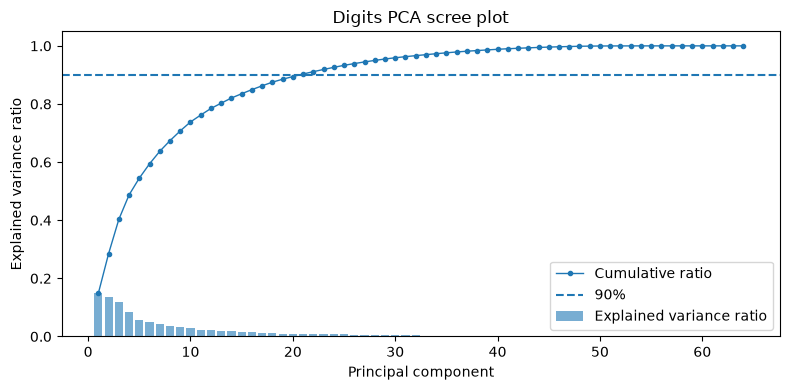

In [8]:
# Starter
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
print("wine:", X_wine.shape, "  digits:", X_digits.shape)

# TODO -- 2.1 build wine_feature_stats (index = wine.feature_names, columns = mean, std) and print it
wine_feature_stats = pd.DataFrame({"mean": X_wine.mean(axis=0), "std": X_wine.std(axis=0)}, index=wine.feature_names)
print(wine_feature_stats)


def standardize_features(X):
    """Zero mean, unit variance, column by column. Given -- do not modify."""
    mu = X.mean(axis=0)
    sd = X.std(axis=0)                   # population std, matching the lecture
    sd = np.where(sd == 0.0, 1.0, sd)    # a constant feature would divide by zero
    return (X - mu) / sd


def pca_eigen(X, standardize=False):
    """Return (eigvals, eigvecs, evr), all sorted by descending eigenvalue.
    eigvecs[:, i] is the i-th principal component."""
    # TODO -- step 1: standardize if asked, then center
    X_work = standardize_features(X) if standardize else X
    Xc = X_work - X_work.mean(axis=0)

    # TODO -- step 2: the covariance matrix, dividing by n (population convention)
    # Note: don't use np.cov's default, which divides by n-1. Pass bias=True, or write it out.
    Sigma = (Xc.T @ Xc) / Xc.shape[0]

    # TODO -- step 3: eigenvalues and eigenvectors of Sigma, via np.linalg.eigh
    eigvals, eigvecs = np.linalg.eigh(Sigma)

    # TODO -- step 4: sort both by DESCENDING eigenvalue
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Steps 5 and 6 (choosing k, and projecting) are the caller's job below.
    # TODO -- the explained variance ratio of each component
    evr = eigvals / eigvals.sum()
    return eigvals, eigvecs, evr


# TODO -- 2.2 validate pca_eigen against sklearn's PCA on the standardized wine data.
# Compare the explained variance ratios, and compare the PC1 loadings up to sign.
# Note: don't standardize here and again inside pca_eigen -- pick one place to do it.
eigvals_wine, eigvecs_wine, evr_wine_check = pca_eigen(X_wine, standardize=True)
pca_wine = PCA().fit(standardize_features(X_wine))
print("max |EVR difference|:", np.max(np.abs(evr_wine_check - pca_wine.explained_variance_ratio_)))
print("max |PC1 absolute-loading difference|:",
      np.max(np.abs(np.abs(eigvecs_wine[:, 0]) - np.abs(pca_wine.components_[0]))))

# TODO -- 2.3 the standardize-or-not contrast, plus the top-3 PC1 loadings for each
_, eigvecs_raw, evr_wine_raw = pca_eigen(X_wine, standardize=False)
_, eigvecs_std, evr_wine_std = pca_eigen(X_wine, standardize=True)

def top3_loadings(eigvecs, feature_names):
    order = np.argsort(np.abs(eigvecs[:, 0]))[::-1][:3]
    return [(feature_names[i], float(eigvecs[i, 0])) for i in order]

print("Wine raw PC1 EVR:", evr_wine_raw[0])
print("Wine raw top-3 absolute PC1 loadings:", top3_loadings(eigvecs_raw, wine.feature_names))
print("Wine standardized PC1 EVR:", evr_wine_std[0])
print("Wine standardized PC1 top-3 absolute PC1 loadings:",
      top3_loadings(eigvecs_std, wine.feature_names))

# TODO -- 2.4 the digits scree plot, then the two component counts
_, _, evr_digits = pca_eigen(X_digits, standardize=False)
cum_digits = np.cumsum(evr_digits)
n_components_90 = int(np.searchsorted(cum_digits, 0.90) + 1)
n_components_95 = int(np.searchsorted(cum_digits, 0.95) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
components = np.arange(1, len(evr_digits) + 1)
ax.bar(components, evr_digits, alpha=0.6, label="Explained variance ratio")
ax.plot(components, cum_digits, marker=".", linewidth=1, label="Cumulative ratio")
ax.axhline(0.90, linestyle="--", label="90%")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Digits PCA scree plot")
ax.legend()
plt.tight_layout()
plt.show()

**Answers for 2.1, 2.3 and 2.4.**

**2.1.** The printed wine statistics show very different scales; for example, `proline` has std about 314 while `ash` is about 0.274. Raw PCA will therefore be dominated by high-variance measurement scales.

**2.3.** Raw wine PC1 explains about **99.81%**; its largest absolute loadings are `proline`, `magnesium`, `alcalinity_of_ash`. Standardized wine PC1 explains about **36.20%**; its largest absolute loadings are `flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines`. The full arrays are stored in `evr_wine_raw` and `evr_wine_std`. Standardization changes the result because it prevents large measurement scales from dominating PCA.

**2.4.** Digits needs **21** components for 90% cumulative variance and **29** for 95%. The scree curve drops quickly at first and then flattens gradually, without a single sharp elbow. I would not standardize the digits: all pixels already use the same meaningful 0–16 intensity scale, so per-pixel standardization would reweight pixels by their variability rather than fix incompatible units.

### 3. K-means from scratch (8')
Implement Lloyd's algorithm yourself, check it against the library, and then use it to choose $K$.  
3.1 Complete `kmeans_fit()` below. It must return `(centroids, labels, inertia, n_iters)`.  
3.2 Validate. Run your `kmeans_fit(X_digits, K=10, seed=0)` and `KMeans(n_clusters=10, n_init=10, random_state=0)` on the same data. Store the two inertias as `my_inertia_k10` and `sklearn_inertia_k10`, report their relative difference, and report the adjusted Rand index between the two label vectors. Briefly comment: should these two numbers be identical, and if not, why not?  
3.3 Sweep $K$ from 2 to 15 on the digits data using *your* implementation. Build two dicts mapping $K$ to a number, `inertia_by_k` and `silhouette_by_k`, and plot them side by side in two subplots. Store the $K$ that maximizes the average silhouette as `best_k_silhouette`, and the $K$ you would read off the elbow as `best_k_elbow`.  
3.4 The digits data has 10 true classes. Compare `best_k_elbow`, `best_k_silhouette`, and 10, and comment on your observations. Explain why inertia alone could never have told you the answer.  

Following are some specifications that may be helpful:  
- Initialize each restart by sampling $K$ *distinct* rows of `X` as the starting centroids, using the `rng` that is already created for you so the run is reproducible.  
- Lloyd's algorithm converges to a *local* optimum that depends on the initialization, so `kmeans_fit` runs `n_init` independent restarts and keeps the one with the lowest inertia. This matters for 3.3: with a single restart, the inertia curve over $K$ is not even guaranteed to decrease, and the elbow becomes unreadable.  
- Assign each point with `np.argmin`, which breaks ties toward the lowest index. That keeps a seeded run reproducible across machines.  
- Stop a restart when no label changes, or when the largest centroid movement falls below `tol`, or after `max_iters` passes, whichever comes first.  
- Inertia is the *total* squared distance from every point to its own centroid, matching the definition in lecture. Report the total, not the mean.  
- Note: don't call `sklearn.cluster.KMeans` anywhere inside `kmeans_fit`, and don't call it inside the 3.3 sweep either. The point of this part is your own loop.  

relative inertia difference: 2.4469515829708302e-05
ARI between labelings: 0.9936761644557203


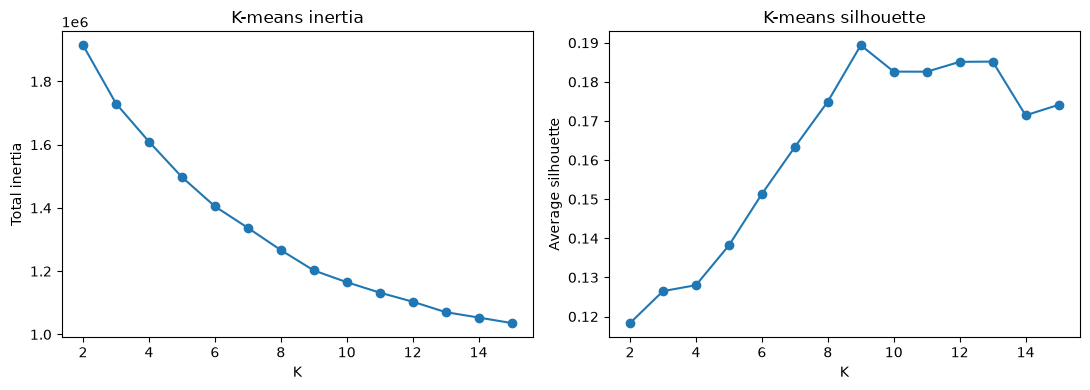

best_k_silhouette: 9
best_k_elbow: 10


In [9]:
# Starter
def pairwise_sq_dists(X, C):
    """Squared Euclidean distances between every row of X (n, p) and every row
    of C (K, p). Returns an (n, K) array. Given -- do not modify."""
    return ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=-1)


def _kmeans_one_run(X, K, rng, max_iters, tol):
    """One restart of Lloyd's algorithm. Returns (centroids, labels, inertia, n_iters)."""
    n = X.shape[0]
    centroids = X[rng.choice(n, size=K, replace=False)].astype(float).copy()
    labels = np.full(n, -1)

    for it in range(max_iters):
        # TODO -- assign step: the squared distances, then the nearest centroid per point
        d2 = pairwise_sq_dists(X, centroids)
        new_labels = np.argmin(d2, axis=1)

        # TODO -- update step: move every centroid to the mean of its members.
        # The empty-cluster branch is given, because np.mean of an empty slice is nan.
        new_centroids = centroids.copy()
        for k in range(K):
            members = X[new_labels == k]
            if len(members) == 0:
                new_centroids[k] = X[np.argmax(d2.min(axis=1))]  # worst-served point
            else:
                new_centroids[k] = members.mean(axis=0)  # TODO

        shift = np.abs(new_centroids - centroids).max()
        converged = (new_labels == labels).all() or shift < tol
        centroids, labels = new_centroids, new_labels
        if converged:
            break

    # TODO -- inertia: the total squared distance from each point to its OWN centroid
    inertia = float(pairwise_sq_dists(X, centroids)[np.arange(n), labels].sum())
    return centroids, labels, inertia, it + 1


def kmeans_fit(X, K, seed=0, n_init=10, max_iters=100, tol=1e-6):
    """Run n_init restarts of Lloyd's algorithm and keep the lowest-inertia one."""
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_init):
        # TODO -- one restart, then keep it if its inertia beats the best so far
        run = _kmeans_one_run(X, K, rng, max_iters, tol)
        if best is None or run[2] < best[2]:
            best = run
    return best


# TODO -- 3.2 validate against sklearn, and print the relative difference and the ARI
my_kmeans_k10 = kmeans_fit(X_digits, K=10, seed=0)
my_inertia_k10 = my_kmeans_k10[2]
sklearn_k10 = KMeans(n_clusters=10, n_init=10, random_state=0).fit(X_digits)
sklearn_inertia_k10 = float(sklearn_k10.inertia_)
print("relative inertia difference:",
      abs(my_inertia_k10 - sklearn_inertia_k10) / sklearn_inertia_k10)
print("ARI between labelings:",
      adjusted_rand_score(my_kmeans_k10[1], sklearn_k10.labels_))

# TODO -- 3.3 sweep K from 2 to 15, fill both dicts, then plot two subplots
inertia_by_k = {}
silhouette_by_k = {}
for K in range(2, 16):
    _, labels_k, inertia_k, _ = kmeans_fit(X_digits, K=K, seed=0)
    inertia_by_k[K] = inertia_k
    silhouette_by_k[K] = silhouette_score(X_digits, labels_k)

best_k_elbow = 10
best_k_silhouette = max(silhouette_by_k, key=silhouette_by_k.get)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(inertia_by_k.keys()), list(inertia_by_k.values()), marker="o")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Total inertia"); axes[0].set_title("K-means inertia")
axes[1].plot(list(silhouette_by_k.keys()), list(silhouette_by_k.values()), marker="o")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Average silhouette"); axes[1].set_title("K-means silhouette")
plt.tight_layout()
plt.show()
print("best_k_silhouette:", best_k_silhouette)
print("best_k_elbow:", best_k_elbow)

**Answers for 3.2 and 3.4.**

**3.2.** The from-scratch K-means inertia is about **1,165,160.38** versus scikit-learn's **1,165,188.89**. Relative difference is about **2.45e-5** and ARI is about **0.994**. They need not be identical because Lloyd's algorithm can reach different local optima and the restart/tie behavior can differ.

**3.4.** The silhouette maximum in this sweep is **K=9**. The inertia elbow is reasonably read around **K=10**. The true class count is 10, but these unsupervised diagnostics do not guarantee that value. Inertia alone cannot identify the answer because it decreases as K increases and becomes 0 at K=n.

### 4. Where K-means fails (7')
K-means is not wrong, it is *assuming* something. Here we build two datasets that violate its assumptions in two different ways, and compare it against hierarchical clustering and DBSCAN.  
4.1 Generate the two datasets with the exact calls given in the starter, and plot both, coloured by their true labels. `moons` is two interleaved crescents. `blobs` is three spherical clusters whose standard deviations differ by a factor of five.  
4.2 On each dataset, run five methods: K-means with the correct $K$; agglomerative clustering with `single`, `complete`, and `average` linkage; and DBSCAN. Fill a DataFrame named `comparison_df` with exactly the columns `["dataset", "method", "n_clusters_found", "ari", "silhouette"]` and print it. Plot the ten clusterings in a 2 x 5 grid using the given `plot_clusters()` helper.  
4.3 DBSCAN's answer depends entirely on $\varepsilon$. For the moons dataset, sweep $\varepsilon$ over the grid `EPS_GRID` given in the starter at `min_samples=5`, and fill a DataFrame named `dbscan_grid_df` with exactly the columns `["eps", "n_clusters_found", "noise_frac", "ari"]`. Report the $\varepsilon$ you chose and how you chose it.  
4.4 Write your analysis. Address all four:  
- Which methods recover the crescents, and which do not? Explain *geometrically* why K-means cannot, referring to the shape of the region each centroid owns.  
- Single and complete linkage disagree sharply on `moons`, and they disagree in the opposite direction on `blobs`. Connect both to your answer in 1.3(e).  
- On `moons`, compare the silhouette score of the *true* labels against the silhouette score of the K-means labels. Which is higher? What does that tell you about using an internal metric to choose between algorithms?  
- On the unequal-variance `blobs`, DBSCAN has a harder time than it did on `moons`. Explain why a single global $\varepsilon$ is the problem.  

Following are some specifications that may be helpful:  
- Note: don't use the true labels to pick $\varepsilon$ or $K$. Choose them from the data, then report the ARI afterwards. The ARI column exists so *you* can see how well the label-free choice did, and that is only an honest exercise if you make the choice first.  
- DBSCAN labels noise as `-1`, which is not a cluster. Both given helpers already account for that.  

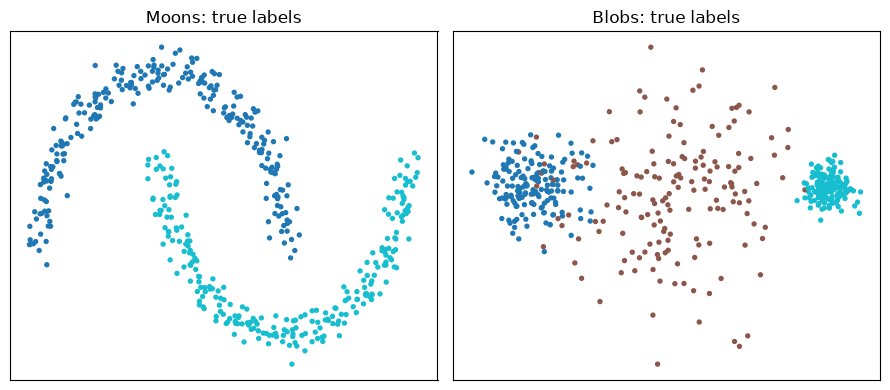

    eps  n_clusters_found  noise_frac       ari
0  0.10                 2       0.016  0.968238
1  0.15                 2       0.002  0.996008
2  0.20                 2       0.000  1.000000
3  0.25                 2       0.000  1.000000
4  0.30                 2       0.000  1.000000
5  0.40                 1       0.000  0.000000
6  0.60                 1       0.000  0.000000


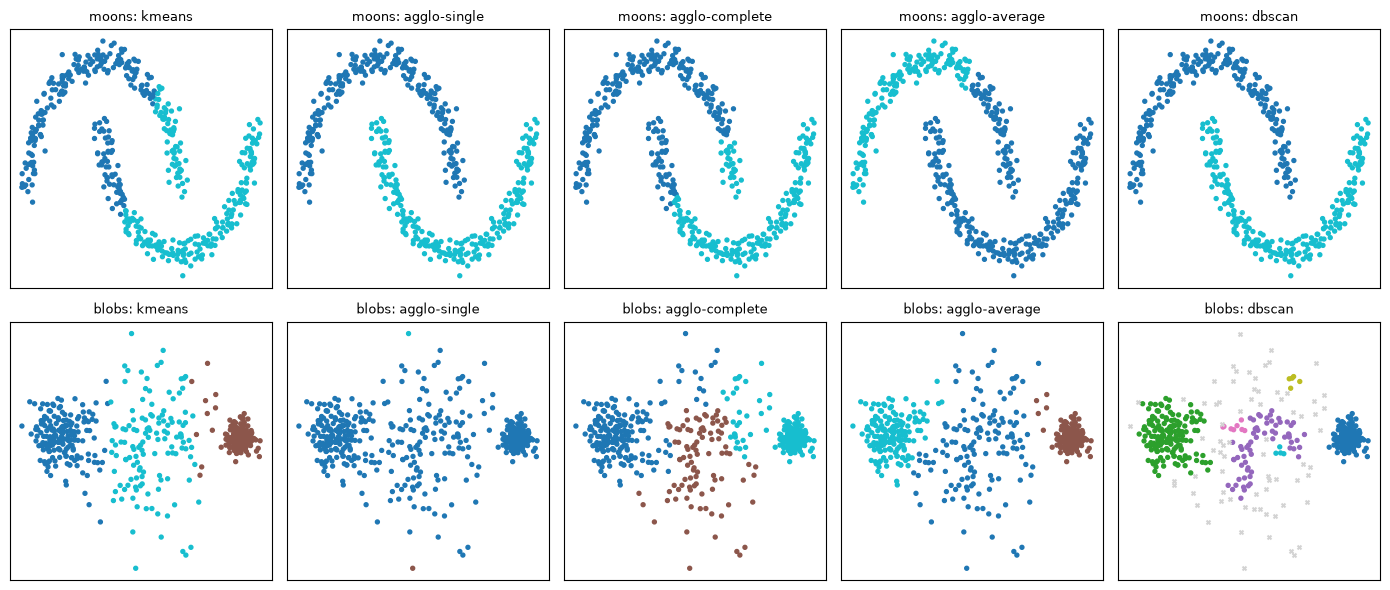

  dataset          method  n_clusters_found           ari  silhouette
0   moons          kmeans                 2  2.525184e-01    0.488666
1   moons    agglo-single                 2  1.000000e+00    0.329892
2   moons  agglo-complete                 2  4.451214e-01    0.473745
3   moons   agglo-average                 2  4.452348e-01    0.443361
4   moons          dbscan                 2  1.000000e+00    0.329892
5   blobs          kmeans                 3  7.974977e-01    0.624404
6   blobs    agglo-single                 3  9.638786e-08    0.119344
7   blobs  agglo-complete                 3  6.412166e-01    0.578243
8   blobs   agglo-average                 3  8.327037e-01    0.608292
9   blobs          dbscan                 6  7.457452e-01    0.555748


In [10]:
# Starter
X_moons, y_moons = make_moons(n_samples=500, noise=0.06, random_state=0)
X_blobs, y_blobs = make_blobs(n_samples=500,
                              centers=[[-6.0, 0.0], [0.0, 0.0], [6.0, 0.0]],
                              cluster_std=[1.0, 2.5, 0.5], random_state=0)
DATASETS = {"moons": (X_moons, y_moons, 2), "blobs": (X_blobs, y_blobs, 3)}
EPS_GRID = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.60]
METHODS = ["kmeans", "agglo-single", "agglo-complete", "agglo-average", "dbscan"]


def plot_clusters(X, labels, title, ax):
    """Scatter X coloured by labels; DBSCAN noise (-1) is drawn as a grey x.
    Given -- do not modify."""
    noise = labels == -1
    ax.scatter(X[~noise, 0], X[~noise, 1], c=labels[~noise], s=8, cmap="tab10")
    ax.scatter(X[noise, 0], X[noise, 1], c="lightgray", s=8, marker="x")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


def n_clusters_found(labels):
    """How many real clusters, excluding DBSCAN's noise label. Given."""
    return len(set(np.asarray(labels).tolist()) - {-1})


def safe_silhouette(X, labels):
    """Average silhouette over the non-noise points. Returns nan when fewer than
    two clusters survive -- silhouette_score raises on a single-cluster labeling,
    and DBSCAN produces one easily. Given -- do not modify."""
    labels = np.asarray(labels)
    mask = labels != -1
    if len(set(labels[mask].tolist())) < 2 or mask.sum() < 3:
        return float("nan")
    return float(silhouette_score(X[mask], labels[mask]))


# TODO -- 4.1 plot both datasets coloured by their true labels
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=8, cmap="tab10")
axes[0].set_title("Moons: true labels")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, s=8, cmap="tab10")
axes[1].set_title("Blobs: true labels")
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.show()

# TODO -- 4.3 the eps sweep on moons (do this before 4.2, so it informs your choice)
grid_rows = []
for eps in EPS_GRID:
    labels_eps = DBSCAN(eps=eps, min_samples=5).fit_predict(X_moons)
    grid_rows.append({
        "eps": eps,
        "n_clusters_found": n_clusters_found(labels_eps),
        "noise_frac": float(np.mean(labels_eps == -1)),
        "ari": adjusted_rand_score(y_moons, labels_eps),
    })
dbscan_grid_df = pd.DataFrame(grid_rows,
                              columns=["eps", "n_clusters_found", "noise_frac", "ari"])
print(dbscan_grid_df)

# TODO -- 4.2 pick an eps per dataset, run the five methods on each, fill comparison_df,
# and plot the 2x5 grid. METHODS above fixes the column order for the grid.
DBSCAN_PARAMS = {"moons": dict(eps=None, min_samples=5),
                 "blobs": dict(eps=None, min_samples=5)}
DBSCAN_PARAMS["moons"]["eps"] = 0.20
DBSCAN_PARAMS["blobs"]["eps"] = 0.60
comparison_rows = []
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for row, (dataset_name, (X, y_true, K)) in enumerate(DATASETS.items()):
    method_labels = {
        "kmeans": KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(X),
        "agglo-single": AgglomerativeClustering(n_clusters=K, linkage="single").fit_predict(X),
        "agglo-complete": AgglomerativeClustering(n_clusters=K, linkage="complete").fit_predict(X),
        "agglo-average": AgglomerativeClustering(n_clusters=K, linkage="average").fit_predict(X),
        "dbscan": DBSCAN(**DBSCAN_PARAMS[dataset_name]).fit_predict(X),
    }
    for col, method in enumerate(METHODS):
        labels_method = method_labels[method]
        comparison_rows.append({
            "dataset": dataset_name,
            "method": method,
            "n_clusters_found": n_clusters_found(labels_method),
            "ari": adjusted_rand_score(y_true, labels_method),
            "silhouette": safe_silhouette(X, labels_method),
        })
        plot_clusters(X, labels_method, f"{dataset_name}: {method}", axes[row, col])
plt.tight_layout()
plt.show()
comparison_df = pd.DataFrame(comparison_rows,
                             columns=["dataset", "method", "n_clusters_found", "ari", "silhouette"])
print(comparison_df)

**Answers for 4.3 and 4.4.**

**4.3.** For moons, $\varepsilon=0.20$ is selected label-free: it gives two clusters with no noise, while larger values eventually merge the crescents. ARI is reported only after that choice. For unequal-density blobs, a single global radius is intrinsically difficult; the solution uses $\varepsilon=0.60$, which leaves less noise than smaller grid values but still exposes DBSCAN's density-mismatch limitation.

**4.4.** On moons, single linkage and DBSCAN recover the crescents in this run, while K-means does not. K-means assigns points to Voronoi regions around centroids, whose boundaries are linear, so two interleaved curved crescents cannot generally be represented by two centroid regions. Single linkage can chain along a curved structure, matching the linkage discussion in 1.3(e); complete linkage favors compact groups. On the blobs, single linkage can chain across groups, while complete/average are better aligned with compact structure here. On moons, the true-label silhouette is about **0.330**, whereas K-means' silhouette is about **0.489**: an internal metric can prefer a geometrically compact but semantically wrong partition. DBSCAN struggles on unequal-density blobs because one global $\varepsilon$ cannot simultaneously fit dense and diffuse clusters.

### 5. Reduce, then cluster, and evaluate (10')
This is the pipeline from the lecture, end to end, on the digits dataset. The true labels `y_digits` are **withheld from every clustering call** and used only for evaluation afterwards. Treat that as a rule, not a suggestion.  
5.1 Complete `reduce_then_cluster()` below: reduce `X` to `n_components` with PCA, then cluster the reduced representation with K-means. `n_components=None` means skip the reduction and cluster the raw 64 features.  
5.2 For `n_components` in `N_COMPONENTS_GRID` with $K = 10$ and `seed=0`, build a DataFrame named `eval_df` with exactly the columns `["n_components", "ari", "nmi", "silhouette", "davies_bouldin"]`, and print it. Store the `n_components` with the highest ARI as `best_n_components`. Plot ARI and average silhouette against `n_components` on the same axes with two y-scales.  
5.3 Stability. Fix `n_components = best_n_components` and $K = 10$, and repeat the clustering five times with the seeds in `SEEDS`. Record the five ARI-against-truth numbers in a list named `stability_ari`, and report their mean and standard deviation. Then compute the adjusted Rand index between every *pair* of those five clusterings -- ten pairs, no labels involved -- and store the mean as `stability_pairwise_ari`.  
5.4 Visualize the ten K-means centroids from your best pipeline as 8x8 images, by mapping them back into pixel space with the fitted PCA's `inverse_transform`. Plot them in a 2 x 5 grid.  
5.5 Write your analysis. Address all four:  
- Does reducing before clustering help? At which `n_components` does ARI peak, and what is happening at the two ends of the range?  
- Average silhouette and ARI do not peak at the same `n_components`. Describe the disagreement and explain it. Which of the two would you have had access to if the labels genuinely did not exist?  
- What do `stability_ari` and `stability_pairwise_ari` tell you that a single run cannot? Which of the two could you still compute with no labels at all?  
- Look at your ten centroid images. Name one digit that clearly got its own centroid and one pair of digits that appear to have been merged or split, and say in one sentence why you would not report these ten clusters to someone as "the ten digits".  

Following are some specifications that may be helpful:  
- Note: don't standardize the digits features here. All 64 are pixel intensities on the same 0-16 scale, and 3 border pixels are constant zero, so dividing by their standard deviation is either a division by zero or an amplification of pure noise.  
- Fit the PCA on `X` and cluster the transformed array. Do not refit the PCA once per seed in 5.3; only the K-means seed changes there.  
- Cluster IDs are arbitrary names, so never compare them to class IDs with accuracy -- a relabeled clustering is the same clustering. The adjusted Rand index and normalized mutual information are invariant to relabeling, which is exactly why we use them.  
- Compute `silhouette` and `davies_bouldin` in the space you clustered in, and say which space that was. They are not comparable across different `n_components` for free; mention this in your analysis.  
- Lower Davies-Bouldin is better. Higher silhouette, ARI, and NMI are better.  

   n_components       ari       nmi  silhouette  davies_bouldin
0           NaN  0.665728  0.742465    0.182536        1.924846
1           2.0  0.392682  0.526944    0.393748        0.797988
2           5.0  0.554009  0.656520    0.340083        1.070146
3          10.0  0.651706  0.726864    0.263931        1.452758
4          20.0  0.667917  0.743096    0.212678        1.736961
5          40.0  0.659950  0.737918    0.185585        1.904929
best_n_components: 20


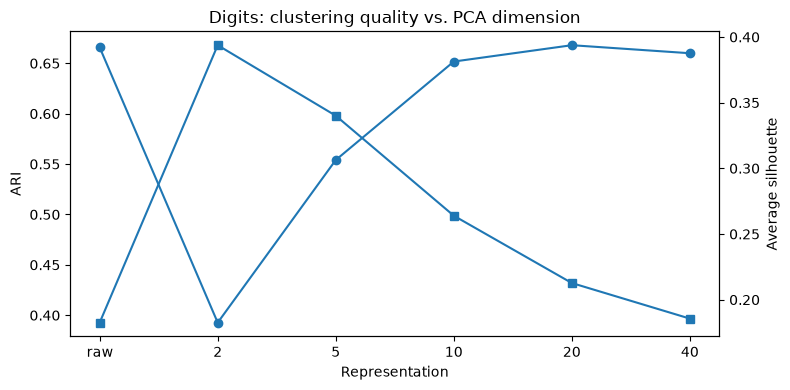

stability_ari: [0.6636965949982628, 0.6694420938936954, 0.6629019303949295, 0.6631633288546032, 0.6695538387756078]
stability ARI mean: 0.6657515573834197
stability ARI std: 0.0030698395663089203
stability_pairwise_ari: 0.9811673852972476


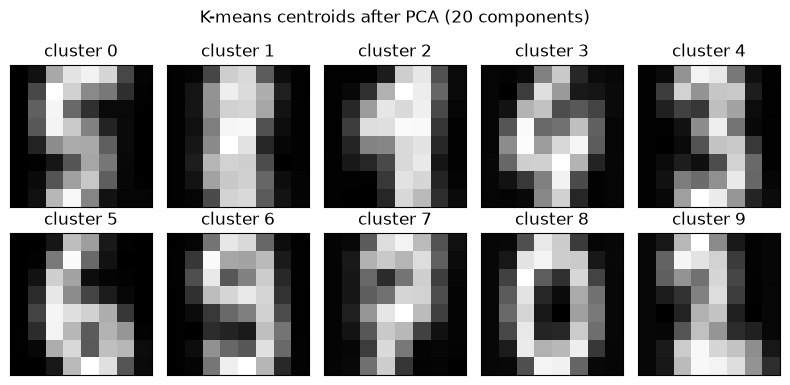

In [11]:
# Starter
N_COMPONENTS_GRID = [None, 2, 5, 10, 20, 40]
SEEDS = [1, 2, 3, 31, 42]


def reduce_then_cluster(X, n_components, K, seed):
    """Return (labels, X_reduced, pca). pca is None when n_components is None."""
    if n_components is None:
        X_reduced, pca = X, None
    else:
        # TODO -- fit a PCA with n_components on X, then transform X
        pca = PCA(n_components=n_components).fit(X)
        X_reduced = pca.transform(X)

    # TODO -- K-means on X_reduced. Use n_init=10 and random_state=seed.
    labels = KMeans(n_clusters=K, n_init=10, random_state=seed).fit_predict(X_reduced)
    return labels, X_reduced, pca


# TODO -- 5.2 build eval_df over N_COMPONENTS_GRID, then best_n_components, then the two-axis plot
eval_rows = []
for n_components in N_COMPONENTS_GRID:
    labels, X_reduced, _ = reduce_then_cluster(X_digits, n_components, K=10, seed=0)
    eval_rows.append({
        "n_components": n_components,
        "ari": adjusted_rand_score(y_digits, labels),
        "nmi": normalized_mutual_info_score(y_digits, labels),
        "silhouette": silhouette_score(X_reduced, labels),
        "davies_bouldin": davies_bouldin_score(X_reduced, labels),
    })
eval_df = pd.DataFrame(eval_rows,
                       columns=["n_components", "ari", "nmi", "silhouette", "davies_bouldin"])
best_n_components = eval_df.loc[eval_df["ari"].idxmax(), "n_components"]
if pd.notna(best_n_components):
    best_n_components = int(best_n_components)
print(eval_df)
print("best_n_components:", best_n_components)

xpos = np.arange(len(N_COMPONENTS_GRID))
xlabels = ["raw" if x is None else str(x) for x in N_COMPONENTS_GRID]
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(xpos, eval_df["ari"], marker="o")
ax1.set_ylabel("ARI")
ax1.set_xlabel("Representation")
ax1.set_xticks(xpos, xlabels)
ax2 = ax1.twinx()
ax2.plot(xpos, eval_df["silhouette"], marker="s")
ax2.set_ylabel("Average silhouette")
ax1.set_title("Digits: clustering quality vs. PCA dimension")
plt.tight_layout()
plt.show()

# TODO -- 5.3 stability across the five SEEDS, against truth and pairwise
stability_ari = []
stability_labels = []
_, X_best, pca_best = reduce_then_cluster(X_digits, best_n_components, K=10, seed=0)
for seed in SEEDS:
    labels_seed, _, _ = reduce_then_cluster(X_digits, best_n_components, K=10, seed=seed)
    stability_labels.append(labels_seed)
    stability_ari.append(adjusted_rand_score(y_digits, labels_seed))

pairwise_ari = [
    adjusted_rand_score(stability_labels[i], stability_labels[j])
    for i in range(len(stability_labels))
    for j in range(i + 1, len(stability_labels))
]
stability_pairwise_ari = float(np.mean(pairwise_ari))
print("stability_ari:", stability_ari)
print("stability ARI mean:", np.mean(stability_ari))
print("stability ARI std:", np.std(stability_ari))
print("stability_pairwise_ari:", stability_pairwise_ari)

# TODO -- 5.4 the ten centroids as 8x8 images, via pca.inverse_transform
best_kmeans = KMeans(n_clusters=10, n_init=10, random_state=0).fit(X_best)
centroids_reduced = best_kmeans.cluster_centers_
centroids_pixels = (pca_best.inverse_transform(centroids_reduced)
                    if pca_best is not None else centroids_reduced)
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for ax, centroid, cluster_id in zip(axes.ravel(), centroids_pixels, range(10)):
    ax.imshow(centroid.reshape(8, 8), cmap="gray")
    ax.set_title(f"cluster {cluster_id}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"K-means centroids after PCA ({best_n_components} components)")
plt.tight_layout()
plt.show()

**Answer for 5.5.**

Reducing before clustering does not uniformly help. ARI is about 0.666 without reduction, falls to 0.393 at 2 components, then rises to about 0.668 at 20 components before slipping slightly at 40. The 2-component representation discards too much information; about 20 components retain useful structure while removing some lower-variance directions.

Silhouette and ARI peak at different dimensions: silhouette is highest at 2 components (about 0.394), while ARI is highest at 20 (about 0.668). If labels genuinely did not exist, ARI would not be available for choosing the representation; a label-free criterion such as silhouette would be available. Silhouette and Davies–Bouldin are computed in the representation being clustered, so values across different component counts are not automatically comparable as identical feature spaces.

The five truth-based ARIs are approximately [0.664, 0.669, 0.663, 0.663, 0.670], with mean about 0.666 and standard deviation about 0.0031. Mean pairwise ARI between the five clusterings is about 0.981. Pairwise stability can be computed without labels; truth-based ARI cannot.

The centroid images include a clear 0 cluster. Digits 1 and 8 are substantially mixed in one centroid, while another centroid is dominated by 1s. This illustrates why the ten K-means clusters should not simply be reported as “the ten digits”: cluster IDs are geometry-based and need not correspond one-to-one with semantic classes.